# CSET Assessment

In [1]:
import os 
import json 
import regex as re
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from  matplotlib.ticker import PercentFormatter
from collections import Counter, defaultdict
from datetime import datetime

from utils import read_word_list, get_category_names

In [2]:
sns.set_theme(style='darkgrid', context='paper')

In [3]:
papers = []
with open(os.path.join('..', 'data', 'arxiv_data.jsonl'), 'r') as file:
    for line in file: 
        papers.append(json.loads(line))

In [4]:
cs_category_map = get_category_names('https://arxiv.org/archive/cs')

## Question 1: Identifying papers about agentic AI

### Question 1.A

In [5]:
# load in pre-defined list of words
narrow_word_list = read_word_list(os.path.join('..', 'word_lists', 'agentic_ai_narrow.txt'))
broad_word_list = read_word_list(os.path.join('..', 'word_lists', 'agentic_ai_broad.txt'))

In [6]:
narrow_matches = set()
broad_matches = set()

# compiling regular expressions outside of loop to improve runtime & remove redundant operations
narrow_regex_patterns = [re.compile(f'(?:\\b)?{word}(:?\\b)?') for word in narrow_word_list]
broad_regex_patterns = [re.compile(f'(?:\\b)?{word}(:?\\b)?') for word in broad_word_list]

for paper in papers:
    title = paper.get('title', '').lower()
    abstract = paper.get('abstract', '').lower()
    paper_id = paper.get('id')

    for pattern in narrow_regex_patterns:
        if pattern.search(title) or pattern.search(abstract):
            narrow_matches.add(paper_id)
            # only need to match one of the patterns to count 
            # cut down run time by ending loop if a match is already found
            break

    for pattern in broad_regex_patterns:
        if pattern.search(title) or pattern.search(abstract):
            broad_matches.add(paper_id)
            # only need to match one of the patterns to count 
            # cut down run time by ending loop if a match is already found
            break

### Question 1.B

In [7]:
cs_ma_papers = set([paper.get('id') for paper in papers if 'cs.ma' in paper.get('categories').lower()])

In [8]:
only_in_cs_ma = cs_ma_papers - broad_matches
only_in_broad_matches = broad_matches - cs_ma_papers
items_not_shared = broad_matches ^ cs_ma_papers

In [9]:
# quick check that set math was done correctly
len(items_not_shared) == (len(only_in_broad_matches) + len(only_in_cs_ma))

True

What repositories were relevant papers in? 

In [10]:
repository_counts = Counter()

for paper in papers: 
    if paper.get('id') in broad_matches:
        repos = paper.get('categories_split')

        for repo in repos:
            repository_counts.update([cs_category_map.get(repo, repo)])

In [11]:
repository_counts.most_common(10)

[('Artificial Intelligence', 4079),
 ('Multiagent Systems', 1861),
 ('Computation and Language', 1690),
 ('Machine Learning', 1656),
 ('Systems and Control', 893),
 ('eess.SY', 817),
 ('Robotics', 727),
 ('Cryptography and Security', 493),
 ('Software Engineering', 481),
 ('math.OC', 478)]

## Question 2: Growth in research on agentic AI

In [12]:
publications_by_year = defaultdict(set)
cs_publications_by_year = defaultdict(set)
agentic_ai_publications_by_year = defaultdict(set)

for paper in papers:
    paper_id = paper.get('id')
    date = paper.get('created')
    year = datetime.fromisoformat(date).year

    publications_by_year[year].add(paper_id)

    if paper_id in broad_matches:
        agentic_ai_publications_by_year[year].add(paper_id)

    if 'cs' in paper.get('categories'):
        cs_publications_by_year[year].add(paper_id)


In [13]:
pct_agentic_ai_publications = {}

for year in list(publications_by_year.keys()):
    agentic_ai_pubs = len(agentic_ai_publications_by_year.get(year, set()))
    overall_pubs = len(publications_by_year.get(year, set()))

    pct_agentic_ai_publications[year] = (agentic_ai_pubs / overall_pubs)

Visualization to show change over time - I am a visual person and find this helpful for interpretting data

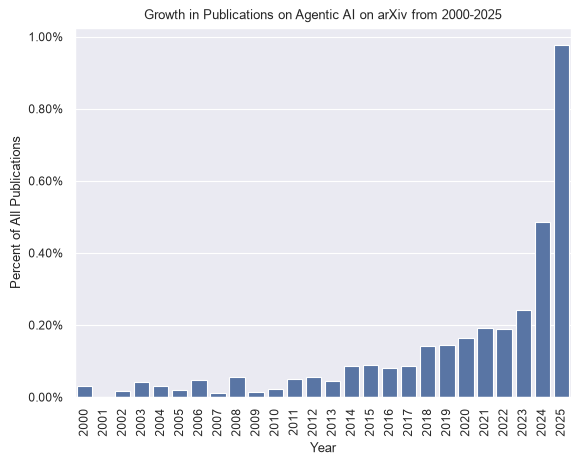

In [14]:
pub_df = pd.DataFrame(pct_agentic_ai_publications.items(), columns=['year', 'pct'])

f = sns.barplot(pub_df[(pub_df['year'] >= 2000) & (pub_df['year'] <= 2025)], x='year', y='pct')
f.set(title='Growth in Publications on Agentic AI on arXiv from 2000-2025', 
      xlabel='Year', 
      ylabel='Percent of All Publications')

_ = plt.xticks(rotation=90)
_ = f.yaxis.set_major_formatter(PercentFormatter(1.0, decimals=2))